## Importing libraries

In [119]:
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
import os
import fiona
import matplotlib.pyplot as plt
import numpy as np

In [120]:
print("Shapely:", shapely.__version__)
print("GeoPandas:", gpd.__version__)
print("Fiona:", fiona.__version__)

#Versions in the standard environment (environment1) for running the model have issues for reading the files with geopandas
#Updates are required and a copy environment (environment2) is used to execute this notebook (geopandas should be >0.10)

Shapely: 1.8.0
GeoPandas: 0.13.2
Fiona: 1.8.20


## Relevant file paths

In [121]:
#Load rough MSR shapes for each technology (before cost assignement)
S1_MSR_pv_file = str(os.path.dirname(os.getcwd())) + r'\1. MSR Creator\Output\Bolivia\Stage4_MSR\solarpv_FinalMSRs.geojson'
S1_MSR_wind_file = str(os.path.dirname(os.getcwd())) + r'\1. MSR Creator\Output\Bolivia\Stage4_MSR\wind_FinalMSRs.geojson'

#Load prescreened MSR shapes (with LCOE and CAPEX values defined) 
S3_MSR_pv_file = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia\SolarPV_prescreen.shp'
S3_MSR_wind_file = str(os.path.dirname(os.getcwd())) + r'\3. Attributor and ShapeFileCombiner\Results-Prescreen_Bolivia\Wind_prescreen.shp'

#Load screened MSR data sets with hourly availabilities (for the top % of resources) 
S4_MSR_pv_file = str(os.path.dirname(os.getcwd())) + r'\4. Screener\Results-Screened_Bolivia\SolarPV_BestMSRsToCover5%CountryArea.csv'
S4_MSR_wind_file = str(os.path.dirname(os.getcwd())) + r'\4. Screener\Results-Screened_Bolivia\Wind_BestMSRsToCover5%CountryArea.csv'


In [122]:
with fiona.open(S3_MSR_pv_file) as src:
    print(src.schema)
    print(src.crs)
    print(len(src))

{'properties': OrderedDict([('FID', 'int:18'), ('AreakM2', 'float:24.15'), ('CapacityMW', 'float:24.15'), ('RoadDist', 'float:24.15'), ('T_Dist_gf', 'float:24.15'), ('D_Dist_gf', 'float:24.15'), ('TD_Dist_gf', 'float:24.15'), ('SubstnDist', 'float:24.15'), ('Load_dst', 'float:24.15'), ('City_name', 'str:80'), ('City_Pop', 'float:24.15'), ('CtLst100kM', 'str:80'), ('CtCnt100kM', 'int:18'), ('PopIn100kM', 'float:24.15'), ('CtryName', 'str:80'), ('GHIkWhm2d', 'str:80'), ('RawERA_GHI', 'float:24.15'), ('CorAdderWh', 'float:24.15'), ('CF', 'float:24.15'), ('Y_GWh', 'float:24.15'), ('sLCOE-MWh', 'float:24.15'), ('tLCOE-MWh', 'float:24.15'), ('tCAPEX-kW', 'float:24.15'), ('rLCOE-MWh', 'float:24.15'), ('rCAPEX-kW', 'float:24.15'), ('LCOE-MWh', 'float:24.15'), ('trCAPEX-kW', 'float:24.15')]), 'geometry': 'Polygon'}
{}
2875


In [123]:
# Read data without geometry (to work with environment1) 
gdf_test = gpd.read_file(S3_MSR_pv_file, ignore_geometry=True)
gdf_test.head()

,FID,AreakM2,CapacityMW,RoadDist,T_Dist_gf,D_Dist_gf,TD_Dist_gf,SubstnDist,Load_dst,City_name,...,CorAdderWh,CF,Y_GWh,sLCOE-MWh,tLCOE-MWh,tCAPEX-kW,rLCOE-MWh,rCAPEX-kW,LCOE-MWh,trCAPEX-kW
0,0,346.112552,1142.171421,2.363358,81.744908,3.189367,3.189367,105.488850,70.519956,Desaguadero,...,3.875478,23.788879,2380.177648,54.852398,7.977104,162.562381,1.088217,20.584379,63.917720,183.146760
1,1,90.414827,298.368931,0.854008,76.509424,2.769399,2.769399,112.741103,87.782535,Desaguadero,...,2.281527,23.728155,620.185590,54.992775,7.724677,157.016433,0.394237,7.438235,63.111689,164.454668
2,2,135.213782,446.205480,0.951578,73.510028,1.824470,1.824470,115.195112,91.397939,Viacha,...,6.879091,23.636638,923.899449,55.205697,7.597670,153.839173,0.440980,8.288053,63.244347,162.127226
3,3,544.158949,1795.724532,1.952397,86.675360,11.720198,11.720198,136.928864,105.557989,Sica Sica,...,12.016862,23.946718,3766.949676,54.490853,8.179126,167.785209,0.893063,17.004987,63.563041,184.790196
4,4,185.463681,612.030146,1.493199,61.805041,6.521498,6.521498,109.438350,86.840098,Viacha,...,8.480691,23.700880,1270.695226,55.056059,6.966381,141.440080,0.690102,13.005465,62.712541,154.445545


## Plotting functions

In [124]:
def region_map (geo_dataframe, key_column, map_title):
    """
    Creates a simple heat map of the selected column/parameter.
    """
    geo_dataframe.plot(column=key_column, legend=True, figsize=(8,6))
    plt.title(map_title)
    plt.show()


In [125]:
def plot_variable_relationship(dataframe, col_x, col_y, add_regression=True):
    """
    Plots the relationship between two variables in a dataframe.
    
    Parameters:
    - df: pandas DataFrame
    - col_x: column name for the independent variable (x-axis)
    - col_y: column name for the dependent variable (y-axis)
    - add_regression: if True, adds a linear regression line
    """

    x = dataframe[col_x]
    y = dataframe[col_y]

    fig, ax = plt.subplots(figsize=(8, 4))

    # Scatter plot
    ax.scatter(x, y, color='blue', alpha=0.6, edgecolor='k', s=60)
    
    # Optional: add linear regression
    if add_regression:
        coeffs = np.polyfit(x, y, deg=1)  # linear regression
        y_fit = np.polyval(coeffs, x)
        ax.plot(x, y_fit, color='red', linestyle='--', linewidth=2,
                label=f'Linear fit: y={coeffs[0]:.2f}x + {coeffs[1]:.2f}')
        ax.legend()

    ax.set_title(f"Relationship between {col_x} and {col_y}")
    ax.set_xlabel(col_x)
    ax.set_ylabel(col_y)
    ax.grid(True)
    
    plt.show()


In [126]:
def generate_supply_curve(geo_dataframe,ranking_col,accumulation_col,ascending=True,):
    """
    Creates a supply curve by sorting a dataframe (geo_dataframe) based on [ranking_col] and 
    accumulating values based on [accumulation_col], using matplotlib.
    """

    # Copy to avoid altering original
    df = geo_dataframe[[ranking_col, accumulation_col]].copy()

    # Sort by chosen metric
    df = df.sort_values(ranking_col, ascending=ascending).reset_index(drop=True)

    # Create cumulative sum
    df["cumulative"] = df[accumulation_col].cumsum()

    # Matplotlib figure
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(df["cumulative"], df[ranking_col], marker='o', linestyle='-')
    
    ax.set_title(f"Supply Curve: {ranking_col} vs cumulative {accumulation_col}")
    ax.set_xlabel(f"Cumulative {accumulation_col}")
    ax.set_ylabel(f"{ranking_col}")

    ax.grid(True)
    
    plt.show()

## File exploration (for prescreend or S3 data)

In [127]:
gdf = gpd.read_file(S3_MSR_wind_file)
gdf.info()
gdf.columns

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1098 entries, 0 to 1097
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   FID         1098 non-null   int64   
 1   AreakM2     1098 non-null   float64 
 2   CapacityMW  1098 non-null   float64 
 3   RoadDist    1098 non-null   float64 
 4   T_Dist_gf   1098 non-null   float64 
 5   D_Dist_gf   1098 non-null   float64 
 6   TD_Dist_gf  1098 non-null   float64 
 7   SubstnDist  1098 non-null   float64 
 8   Load_dst    1098 non-null   float64 
 9   City_name   1098 non-null   object  
 10  City_Pop    1098 non-null   float64 
 11  CtLst100kM  800 non-null    object  
 12  CtCnt100kM  1098 non-null   int64   
 13  PopIn100kM  1098 non-null   float64 
 14  CtryName    1098 non-null   object  
 15  MeanSpeed   1098 non-null   object  
 16  IEC_Class   1098 non-null   object  
 17  ERA_WSpeed  1098 non-null   float64 
 18  CF100m      1098 non-null   float64 
 19

Index(['FID', 'AreakM2', 'CapacityMW', 'RoadDist', 'T_Dist_gf', 'D_Dist_gf',
       'TD_Dist_gf', 'SubstnDist', 'Load_dst', 'City_name', 'City_Pop',
       'CtLst100kM', 'CtCnt100kM', 'PopIn100kM', 'CtryName', 'MeanSpeed',
       'IEC_Class', 'ERA_WSpeed', 'CF100m', 'Y_GWh100m', 'sLCOE-MWh',
       'tLCOE-MWh', 'tCAPEX-kW', 'rLCOE-MWh', 'rCAPEX-kW', 'LCOE-MWh',
       'trCAPEX-kW', 'geometry'],
      dtype='object')

In [128]:
gdf.head()

,FID,AreakM2,CapacityMW,RoadDist,T_Dist_gf,D_Dist_gf,TD_Dist_gf,SubstnDist,Load_dst,City_name,...,CF100m,Y_GWh100m,sLCOE-MWh,tLCOE-MWh,tCAPEX-kW,rLCOE-MWh,rCAPEX-kW,LCOE-MWh,trCAPEX-kW,geometry
0,0,152.806260,449.250405,1.201183,6.791024,2.393051,2.393051,34.994978,21.379872,Montero,...,44.773857,1762.045401,47.551941,2.168247,83.163732,0.293863,10.462067,50.014050,93.625799,"POLYGON ((-6170447.880 -2147198.864, -6170147...."
1,1,209.618699,616.278976,1.244803,3.597729,2.410556,2.410556,19.970997,15.999640,Santa Cruz1,...,46.303758,2499.756433,45.980800,2.011328,79.781074,0.294472,10.841983,48.286600,90.623057,"POLYGON ((-6169846.689 -2164332.817, -6169546...."
2,2,22.950870,67.475558,0.711849,11.408714,0.888841,0.888841,15.603627,10.721693,Santa Cruz1,...,43.733884,258.504818,41.943658,2.350371,88.055250,0.178291,6.200061,44.472320,94.255311,"POLYGON ((-6156094.437 -2195895.362, -6156319...."
3,3,278.516488,818.838475,0.608752,8.425069,1.252322,1.252322,30.386299,24.486972,Montero,...,44.876385,3218.994339,47.443300,2.208319,84.894676,0.148587,5.302104,49.800207,90.196780,"POLYGON ((-6156019.288 -2157419.116, -6156019...."
4,4,252.448276,742.197930,0.649362,2.751796,2.260233,2.260233,11.733223,11.284314,Santa Cruz1,...,40.831234,2654.705514,44.925389,2.255283,78.884977,0.174202,5.655814,47.354874,84.540791,"POLYGON ((-6155418.097 -2177859.622, -6155418...."


In [ ]:
#check cordinate reference system 
gdf.crs

#and change the crs to the WGS84 ellipsoid
gdf = gdf.to_crs("EPSG:4326")
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World: Afghanistan, Albania, Algeria, American Samoa, Andorra, Angola, Anguilla, Antarctica, Antigua and Barbuda, Argentina, Armenia, Aruba, Australia, Austria, Azerbaijan, Bahamas, Bahrain, Bangladesh, Barbados, Belgium, Belgium, Belize, Benin, Bermuda, Bhutan, Bolivia, Bonaire, Saint Eustasius and Saba, Bosnia and Herzegovina, Botswana, Bouvet Island, Brazil, British Indian Ocean Territory, British Virgin Islands, Brunei Darussalam, Bulgaria, Burkina Faso, Burundi, Cambodia, Cameroon, Canada, Cape Verde, Cayman Islands, Central African Republic, Chad, Chile, China, Christmas Island, Cocos (Keeling) Islands, Comoros, Congo, Cook Islands, Costa Rica, Côte d'Ivoire (Ivory Coast), Croatia, Cuba, Curacao, Cyprus, Czechia, Denmark, Djibouti, Dominica, Dominican Republic, East Timor, Ecuador, Egypt, El Salvador, Equatoria

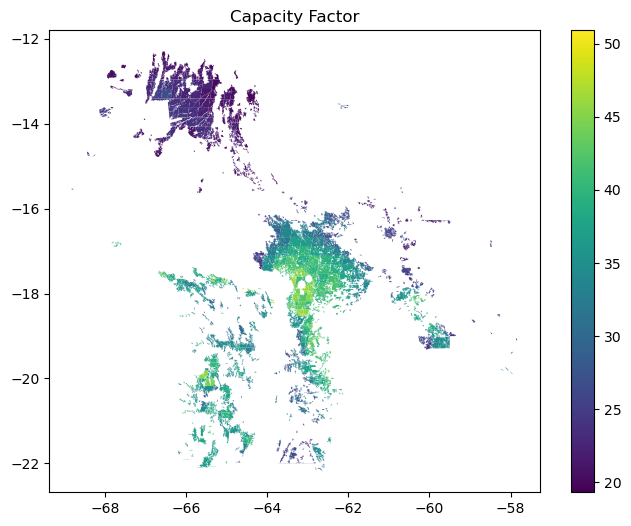

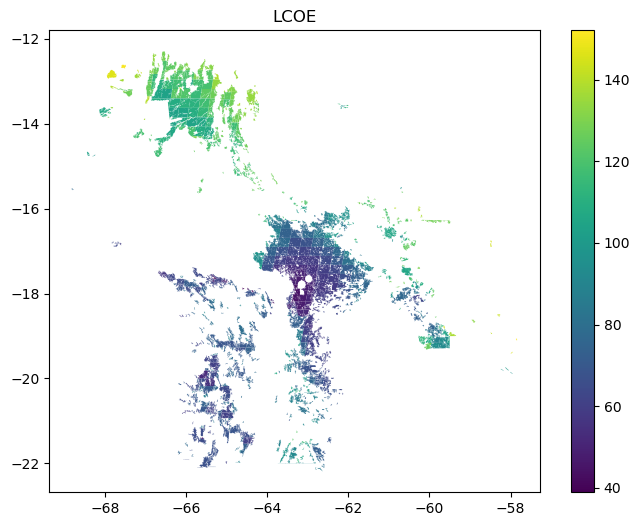

In [132]:
region_map(geo_dataframe=gdf, key_column="CF100m", map_title="Capacity Factor")
region_map(geo_dataframe=gdf, key_column="LCOE-MWh", map_title="LCOE")

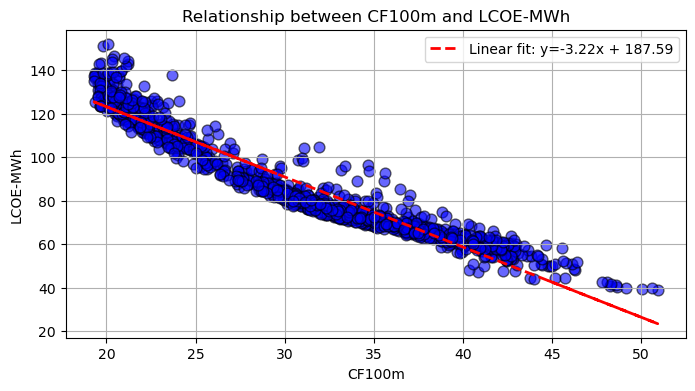

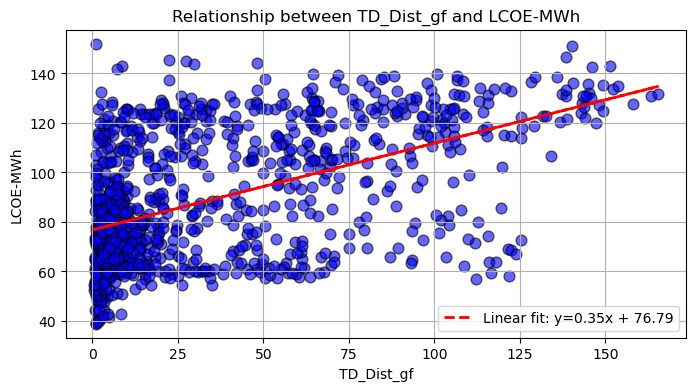

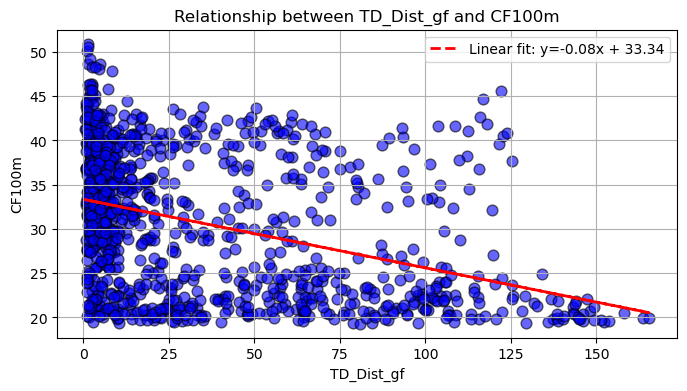

In [134]:
plot_variable_relationship(dataframe=gdf, col_x='CF100m',col_y='LCOE-MWh',add_regression=True)
plot_variable_relationship(dataframe=gdf, col_x='TD_Dist_gf',col_y='LCOE-MWh',add_regression=True)
plot_variable_relationship(dataframe=gdf, col_x='TD_Dist_gf',col_y='CF100m',add_regression=True)

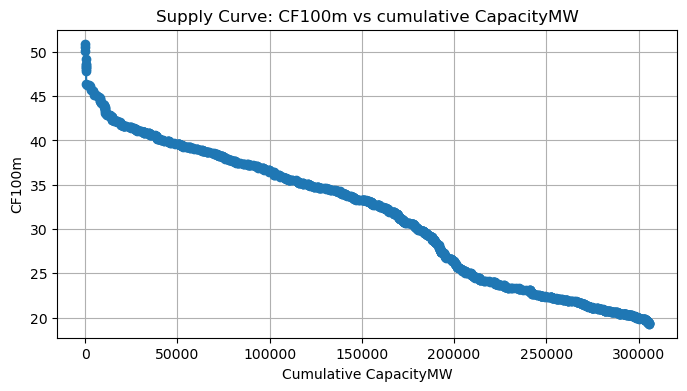

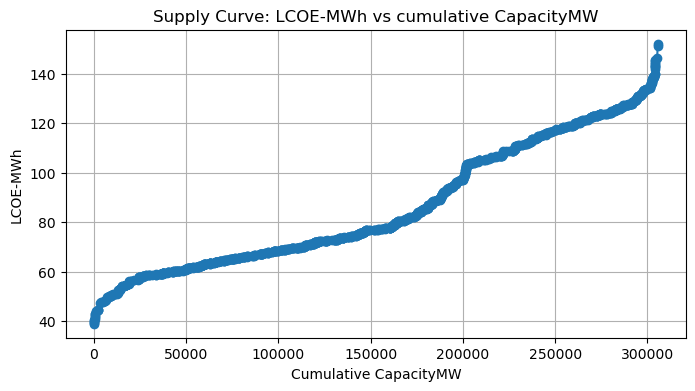

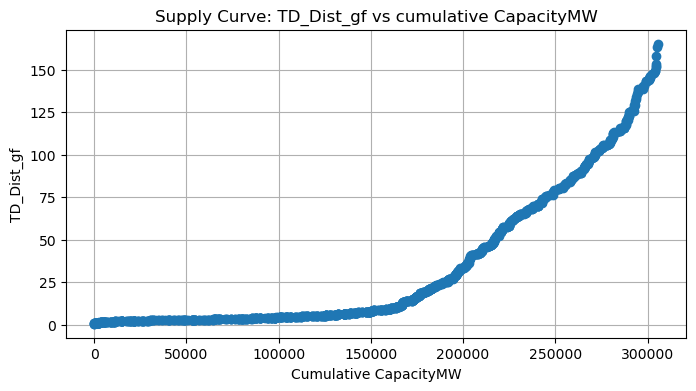

In [135]:
generate_supply_curve(geo_dataframe=gdf,ranking_col="CF100m",accumulation_col="CapacityMW",ascending=False)
generate_supply_curve(geo_dataframe=gdf,ranking_col="LCOE-MWh",accumulation_col="CapacityMW",ascending=True)
generate_supply_curve(geo_dataframe=gdf,ranking_col="TD_Dist_gf",accumulation_col="CapacityMW",ascending=True)